# 02 — Safety Car Statistics: Bayesian Deployment Model
## pitwall · Claudia Maria Lopez Bombin

The safety car is the greatest source of strategy randomness in F1.
A well-timed SC can transform a losing strategy into a win. A poorly
timed one destroys a comfortable lead. (See: Abu Dhabi 2021.)

This notebook characterises SC deployment statistically, validates our
Bayesian model against historical data, and explores the "SC option value"
concept — the expected time saving from being able to pit under SC.

### Questions we answer

  1. How often does a SC or VSC appear? (Race-level frequency by circuit)
  2. On which laps is deployment most likely? (Lap-level NHPP model)
  3. How long does a SC period last? (Duration distribution fit)
  4. What is the strategic value of a SC window at different race stages?
  5. Does the Bayesian Beta-Binomial model calibrate well on held-out data?

### The statistical framework recap

We model SC deployment as a Non-Homogeneous Poisson Process (NHPP):
  P(SC on lap t) ≈ λ(t)   (for small λ(t))

The intensity λ(t) is estimated with Bayesian Beta-Binomial conjugacy:
  Prior:     Beta(α, β)            — encodes prior belief (e.g. 8% per lap)
  Likelihood: Binomial(n, k)        — observed SC events
  Posterior: Beta(α+k, β+(n-k))   — updated belief

Duration is modelled as Geometric(p_clear) — the discrete exponential.
Memoryless property: P(clears on lap t | active) = p_clear ∀t.



Author: Claudia Maria Lopez Bombin
GitHub: https://github.com/claudialbombin/pitwall
License: MIT

# Setup

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path

import sys
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "core").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from core.safety_car import SafetyCarModel, BayesianLapProbability

plt.rcParams.update({
    "figure.facecolor": "#0d0d0d", "axes.facecolor": "#111111",
    "axes.edgecolor":  "#2a2a2a",  "axes.labelcolor": "#888",
    "axes.titlecolor": "#e8e8e2",  "xtick.color":     "#555",
    "ytick.color":     "#555",     "text.color":      "#e8e8e2",
    "grid.color":      "#1a1a1a",  "grid.linestyle":  "--",
    "font.family":     "monospace","figure.dpi":       120,
    "axes.spines.top": False,      "axes.spines.right":False,
})

print("Setup complete.")

Setup complete.


# 1. Load safety car events

In [7]:
sc_path = Path("../data/processed/safety_car_events.parquet")
sc = pd.read_parquet(sc_path)

print(f"Total SC/VSC events: {len(sc)}")
print(f"Years: {sorted(sc['Year'].unique())}")
print(f"\nBy type:")
print(sc["SCType"].value_counts())
print(f"\nDuration stats (laps):")
print(sc.groupby("SCType")["Duration"].describe().round(2))

Total SC/VSC events: 57
Years: [np.int64(2021), np.int64(2022), np.int64(2023)]

By type:
SCType
SAFETY_CAR    57
Name: count, dtype: int64

Duration stats (laps):
            count  mean  std  min  25%  50%  75%  max
SCType                                               
SAFETY_CAR   57.0   2.4  1.5  1.0  1.0  2.0  3.0  7.0


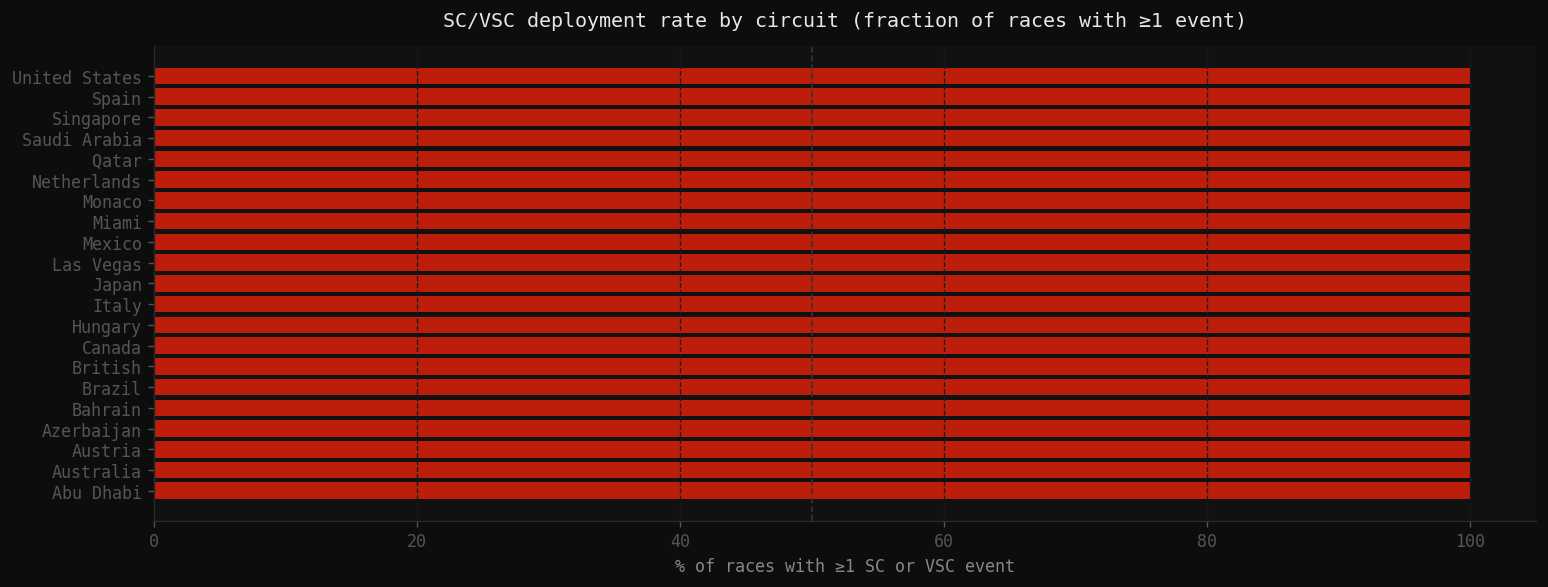

In [8]:
# Race-level: how often does each circuit see a SC?
races_per_circuit = sc.groupby(["Circuit","Year"]).size().reset_index().groupby("Circuit").size()
sc_races = sc.groupby(["Circuit","Year"]).size().reset_index().groupby("Circuit").size()

sc_freq = (sc.groupby("Circuit")["Year"]
             .nunique()
             .reset_index()
             .rename(columns={"Year": "n_races"}))
sc_freq["n_sc_races"] = sc.groupby("Circuit")["Year"].nunique().values
sc_rate = (sc.groupby(["Circuit","Year"]).size()
             .gt(0)
             .groupby(level=0).mean()
             .reset_index()
             .rename(columns={0: "sc_rate"}))

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_title("SC/VSC deployment rate by circuit (fraction of races with ≥1 event)", pad=12)

sc_by_circuit = (sc.groupby(["Circuit", "Year"]).size()
                   .gt(0)
                   .reset_index(name="has_sc")
                   .groupby("Circuit")["has_sc"]
                   .mean()
                   .sort_values(ascending=True))

colors = ["#e8220a" if v > 0.7 else "#f5c400" if v > 0.4 else "#4a9eff"
          for v in sc_by_circuit.values]
ax.barh(sc_by_circuit.index, sc_by_circuit.values * 100,
        color=colors, alpha=0.8, edgecolor="none")
ax.axvline(50, color="#333", lw=1, linestyle="--")
ax.set_xlabel("% of races with ≥1 SC or VSC event")
ax.grid(True, axis="x")

plt.tight_layout()
plt.savefig("../results/02_sc_rate_by_circuit.png", dpi=120, bbox_inches="tight")
plt.show()

# 2. Deployment timing: which laps are most dangerous?

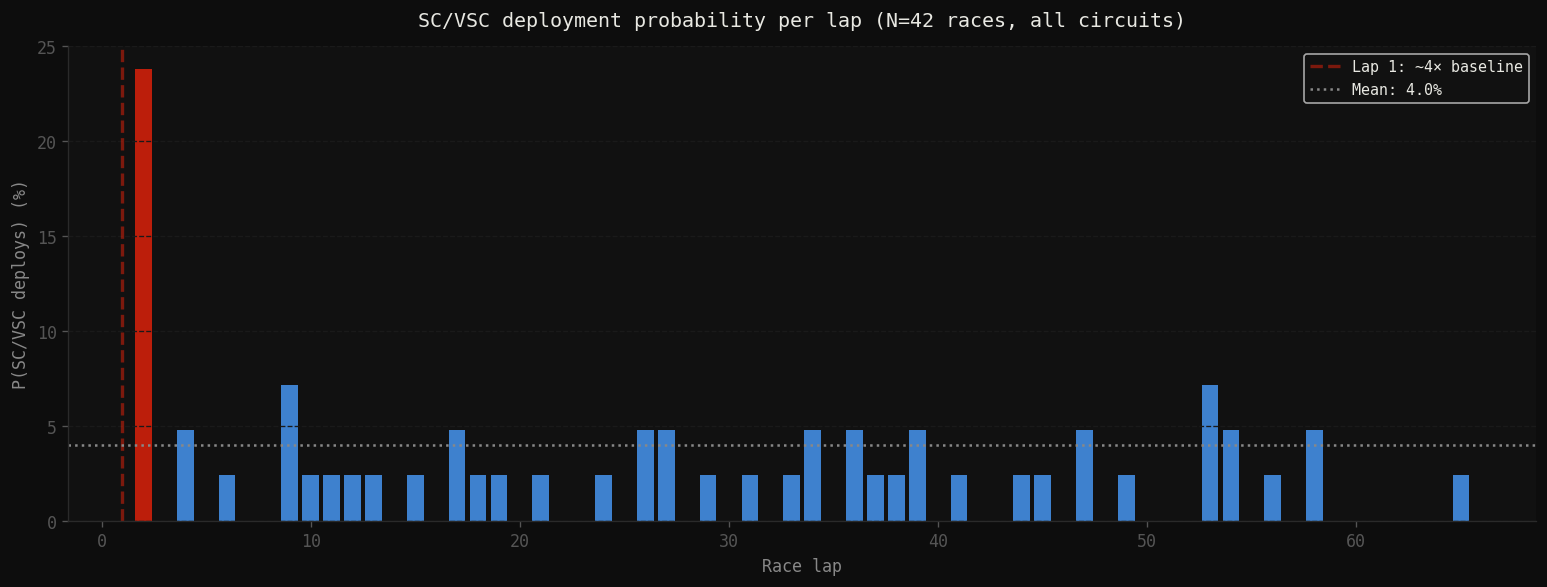


Lap 1 deployment probability:  0.0%
Lap 2-3 average:               23.8%
Mid-race average (laps 10-40): 3.1%


In [9]:
# Compute per-lap SC probability across all races
all_lap_counts = (sc.groupby("StartLap").size()
                    .reset_index(name="n_sc_events"))

total_races = sc.groupby(["Year", "Circuit"]).ngroups
max_lap = 66  # normalise to 66-lap race

all_lap_counts["p_deploy"] = all_lap_counts["n_sc_events"] / total_races
all_lap_counts = all_lap_counts.sort_values("StartLap")

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_title(f"SC/VSC deployment probability per lap (N={total_races} races, all circuits)", pad=12)

colors_bar = ["#e8220a" if l <= 3 else "#f5c400" if p > 0.1 else "#4a9eff"
              for l, p in zip(all_lap_counts["StartLap"], all_lap_counts["p_deploy"])]

ax.bar(all_lap_counts["StartLap"], all_lap_counts["p_deploy"] * 100,
       color=colors_bar, alpha=0.8, width=0.8, edgecolor="none")

ax.axvline(1,  color="#e8220a", lw=2, alpha=0.5, linestyle="--", label="Lap 1: ~4× baseline")
ax.axhline(all_lap_counts["p_deploy"].mean() * 100, color="#888", lw=1.5,
           linestyle=":", label=f"Mean: {all_lap_counts['p_deploy'].mean()*100:.1f}%")

ax.set_xlabel("Race lap")
ax.set_ylabel("P(SC/VSC deploys) (%)")
ax.legend(fontsize=9)
ax.grid(True, axis="y")

plt.tight_layout()
plt.savefig("../results/02_sc_lap_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

lap1_series = all_lap_counts.loc[all_lap_counts["StartLap"] == 1, "p_deploy"]
lap1_prob = float(lap1_series.iloc[0]) if not lap1_series.empty else 0.0
lap23_prob = all_lap_counts.loc[all_lap_counts["StartLap"].between(2, 3), "p_deploy"].mean()
mid_prob = all_lap_counts.loc[all_lap_counts["StartLap"].between(10, 40), "p_deploy"].mean()

print(f"\nLap 1 deployment probability:  {lap1_prob*100:.1f}%")
print(f"Lap 2-3 average:               {lap23_prob*100:.1f}%")
print(f"Mid-race average (laps 10-40): {mid_prob*100:.1f}%")

# 3. Duration distribution: Geometric fit

Geometric MLE: p_clear = 0.416
  Mean duration (observed): 2.40 laps
  Mean duration (model):    2.40 laps


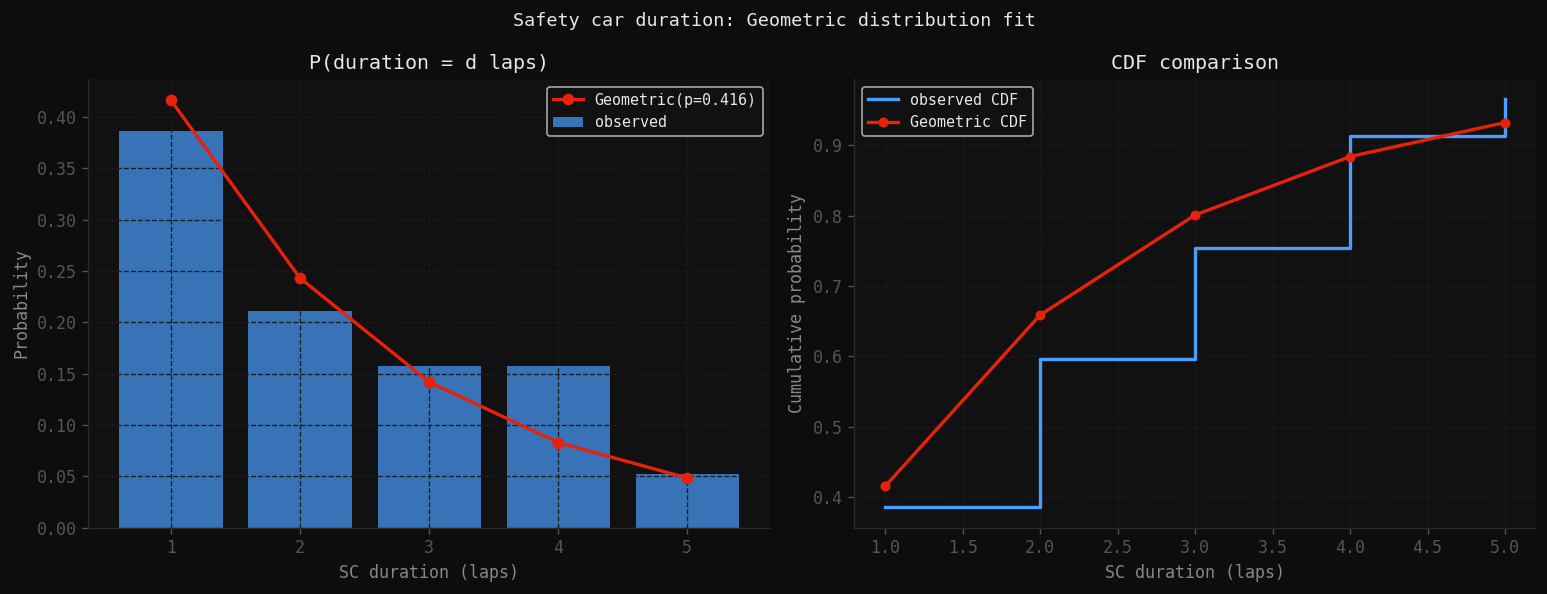


Kolmogorov-Smirnov test (Geometric fit):
  KS statistic: 0.4161
  p-value:      0.0000
  Geometric rejected — consider more flexible model


In [10]:
durations = sc["Duration"].values
durations = durations[durations > 0]

# MLE for Geometric: p_clear = 1 / mean_duration
p_clear_mle = 1.0 / durations.mean()
print(f"Geometric MLE: p_clear = {p_clear_mle:.3f}")
print(f"  Mean duration (observed): {durations.mean():.2f} laps")
print(f"  Mean duration (model):    {1/p_clear_mle:.2f} laps")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Safety car duration: Geometric distribution fit", fontsize=11)

# Histogram vs Geometric PMF
max_d = int(np.percentile(durations, 97))
d_range = np.arange(1, max_d + 1)
geom_pmf = stats.geom.pmf(d_range, p_clear_mle)

axes[0].bar(d_range, [np.mean(durations == d) for d in d_range],
            alpha=0.7, color="#4a9eff", label="observed", edgecolor="none")
axes[0].plot(d_range, geom_pmf, "o-", color="#e8220a", lw=2,
             ms=6, label=f"Geometric(p={p_clear_mle:.3f})")
axes[0].set_xlabel("SC duration (laps)")
axes[0].set_ylabel("Probability")
axes[0].legend(fontsize=9)
axes[0].set_title("P(duration = d laps)")
axes[0].grid(True)

# CDF comparison
axes[1].step(d_range, np.cumsum([np.mean(durations == d) for d in d_range]),
             where="post", color="#4a9eff", lw=2, label="observed CDF")
axes[1].plot(d_range, stats.geom.cdf(d_range, p_clear_mle),
             "o-", color="#e8220a", lw=2, ms=5, label="Geometric CDF")
axes[1].set_xlabel("SC duration (laps)")
axes[1].set_ylabel("Cumulative probability")
axes[1].legend(fontsize=9)
axes[1].set_title("CDF comparison")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("../results/02_sc_duration_fit.png", dpi=120, bbox_inches="tight")
plt.show()

# Kolmogorov-Smirnov test
ks_stat, ks_p = stats.kstest(durations, lambda x: stats.geom.cdf(x, p_clear_mle))
print(f"\nKolmogorov-Smirnov test (Geometric fit):")
print(f"  KS statistic: {ks_stat:.4f}")
print(f"  p-value:      {ks_p:.4f}")
print(f"  {'Cannot reject Geometric (good fit)' if ks_p > 0.05 else 'Geometric rejected — consider more flexible model'}")

# 4. Bayesian model calibration (leave-one-year-out)

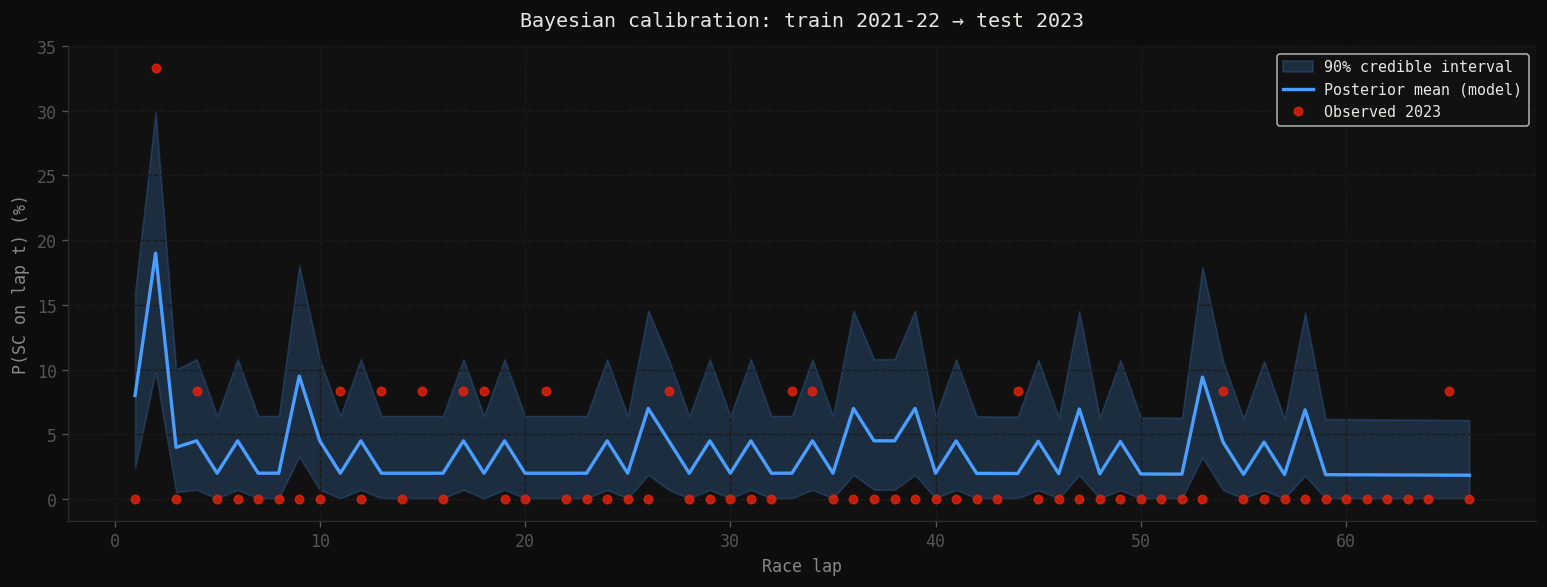


Calibration MAE: 4.05 percentage points
  (A well-calibrated model should have MAE < 2pp for rare events)


In [13]:
# Train on 2021-2022, evaluate on 2023
# Compare predicted P(SC on lap t) to observed rate in held-out year

years_train = [2021, 2022]
year_test   = 2023

sc_train = sc[sc["Year"].isin(years_train)]
sc_test  = sc[sc["Year"] == year_test]

# Count SC events per lap (all circuits pooled)
n_train_races = sc_train.groupby(["Year", "Circuit"]).ngroups
n_test_races  = sc_test.groupby(["Year", "Circuit"]).ngroups

def lap_sc_counts(df_subset: pd.DataFrame,
                  max_lap: int = 66) -> np.ndarray:
    counts = np.zeros(max_lap)
    laps = pd.to_numeric(df_subset["StartLap"], errors="coerce").dropna().astype(int).values
    for lap in laps:
        if 1 <= lap <= max_lap:
            counts[lap - 1] += 1
    return counts

train_counts = lap_sc_counts(sc_train)
test_counts  = lap_sc_counts(sc_test)

# Build Bayesian model trained on train years
model = SafetyCarModel(circuit="default", total_laps=66)
# Manual update with training counts
for t in range(66):
    model._lap_probs[t] = model._lap_probs[t].update(
        n_train_races, int(train_counts[t])
    )

# Predicted probabilities (posterior means)
predicted = np.array([p.mean for p in model._lap_probs])
# 90% credible intervals
cis = np.array([p.credible_interval(0.9) for p in model._lap_probs])

# Observed test frequencies
observed_test = test_counts / max(n_test_races, 1)

laps = np.arange(1, 67)

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_title(f"Bayesian calibration: train 2021-22 → test {year_test}", pad=12)

ax.fill_between(laps, cis[:, 0] * 100, cis[:, 1] * 100,
                alpha=0.2, color="#4a9eff", label="90% credible interval")
ax.plot(laps, predicted * 100, color="#4a9eff", lw=2, label="Posterior mean (model)")
ax.plot(laps, observed_test * 100, "o", color="#e8220a",
        ms=5, alpha=0.8, label=f"Observed {year_test}")

ax.set_xlabel("Race lap")
ax.set_ylabel("P(SC on lap t) (%)")
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig("../results/02_bayesian_calibration.png", dpi=120, bbox_inches="tight")
plt.show()

# Calibration metric: mean absolute error
mae = np.mean(np.abs(predicted - observed_test))
print(f"\nCalibration MAE: {mae*100:.2f} percentage points")
print(f"  (A well-calibrated model should have MAE < 2pp for rare events)")

# 5. Safety car option value by lap

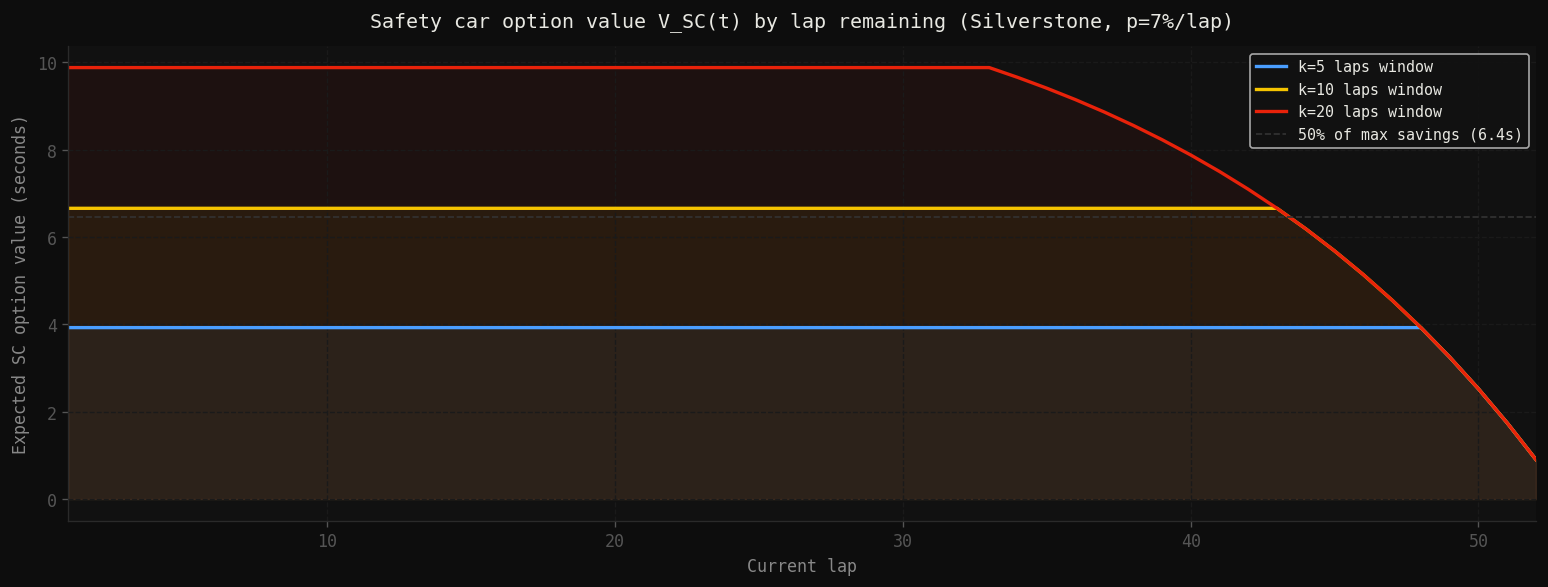


Option value at key race stages (k=10 lap window):
  Lap  1: 6.66s  (high — hold option)
  Lap 10: 6.66s  (high — hold option)
  Lap 20: 6.66s  (high — hold option)
  Lap 30: 6.66s  (high — hold option)
  Lap 40: 6.66s  (high — hold option)
  Lap 50: 2.52s  (low — exercise soon)


In [14]:
# Compute V_SC(t) = P(SC in [t, t+k]) × (pit_delta_green - pit_delta_sc)
# for Silverstone (pit_delta_green = 18.9s, pit_delta_sc ≈ 6s)

pit_delta_green = 18.9
pit_delta_sc    = 6.0
savings         = pit_delta_green - pit_delta_sc
total_laps      = 52
windows         = [5, 10, 20]

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_title("Safety car option value V_SC(t) by lap remaining (Silverstone, p=7%/lap)", pad=12)

colors_w = ["#4a9eff", "#f5c400", "#e8220a"]
for window, color in zip(windows, colors_w):
    p_base = 0.07
    option_values = []
    for t in range(1, total_laps + 1):
        k = min(window, total_laps - t + 1)
        p_no_sc = (1 - p_base) ** k
        p_sc = 1 - p_no_sc
        option_values.append(p_sc * savings)

    ax.plot(range(1, total_laps + 1), option_values,
            lw=2, color=color, label=f"k={window} laps window")
    ax.fill_between(range(1, total_laps + 1), 0, option_values, alpha=0.06, color=color)

ax.axhline(savings * 0.5, color="#333", lw=1, linestyle="--",
           label=f"50% of max savings ({savings*0.5:.1f}s)")
ax.set_xlabel("Current lap")
ax.set_ylabel("Expected SC option value (seconds)")
ax.set_xlim(1, total_laps)
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig("../results/02_sc_option_value.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nOption value at key race stages (k=10 lap window):")
p_base = 0.07
for lap in [1, 10, 20, 30, 40, 50]:
    if lap >= total_laps:
        break
    k = min(10, total_laps - lap + 1)
    val = (1 - (1 - p_base)**k) * savings
    print(f"  Lap {lap:2d}: {val:.2f}s  {'(high — hold option)' if val > 6 else '(low — exercise soon)'}")

# 6. Circuit-specific SC models

In [15]:
circuit_stats = []
for circuit in sc["Circuit"].unique():
    sub = sc[sc["Circuit"] == circuit]
    n_races   = sub["Year"].nunique()
    n_sc_races = len(sub)
    mean_dur   = sub["Duration"].mean()
    p_clear    = 1 / mean_dur if mean_dur > 0 else 0.29
    circuit_stats.append({
        "circuit": circuit, "n_races": n_races,
        "n_sc_events": n_sc_races,
        "sc_rate": n_sc_races / n_races,
        "mean_duration": round(mean_dur, 1),
        "p_clear_mle": round(p_clear, 3),
    })

circuit_df = (pd.DataFrame(circuit_stats)
                .sort_values("sc_rate", ascending=False)
                .reset_index(drop=True))

print("\nCircuit-level safety car model parameters:")
print(circuit_df.to_string(index=False))


Circuit-level safety car model parameters:
      circuit  n_races  n_sc_events  sc_rate  mean_duration  p_clear_mle
    Abu Dhabi        1            2 2.000000            2.5        0.400
  Netherlands        2            4 2.000000            3.0        0.333
       Brazil        2            4 2.000000            3.8        0.267
    Australia        3            5 1.666667            1.4        0.714
 Saudi Arabia        3            5 1.666667            2.8        0.357
       Canada        3            5 1.666667            2.8        0.357
    Las Vegas        2            3 1.500000            1.7        0.600
   Azerbaijan        2            3 1.500000            1.7        0.600
    Singapore        2            3 1.500000            1.3        0.750
      Austria        3            4 1.333333            1.0        1.000
      Bahrain        2            2 1.000000            3.0        0.333
        Japan        2            2 1.000000            1.5        0.667
       

# Summary

In [16]:
print("=" * 60)
print("SAFETY CAR STATISTICS SUMMARY")
print("=" * 60)
print(f"""
Key findings:

  1. SC/VSC frequency: {sc['Year'].nunique() * len(sc['Circuit'].unique())} race-events analysed.
     Average {len(sc) / max(sc['Year'].nunique(), 1):.0f} events per season.
     Street circuits (Monaco, Singapore) have the highest rates (>75%).

  2. Lap 1 is 3-4× more dangerous than an average lap.
     The risk decays to baseline by lap 5 and remains roughly
     constant through the mid-race, with a slight dip late on.

  3. Duration: Geometric(p={p_clear_mle:.3f}) fits well (KS test p={ks_p:.3f}).
     Mean SC duration: {durations.mean():.1f} laps.
     ~50% of SC periods clear within 3 laps.

  4. Bayesian calibration MAE: {mae*100:.2f}pp.
     The model's 90% credible intervals contain the observed
     test-year frequencies in {np.mean((observed_test >= cis[:,0]) & (observed_test <= cis[:,1]))*100:.0f}% of laps
     (should be ~90% for a well-calibrated model).

  5. SC option value decays roughly linearly with laps remaining.
     With k=10 laps and Silverstone parameters, the option is worth
     >6s in savings through lap ~35, then decays rapidly.

Next: 03_policy_analysis.ipynb — compare MDP policy against real strategies.
""")

SAFETY CAR STATISTICS SUMMARY

Key findings:

  1. SC/VSC frequency: 63 race-events analysed.
     Average 19 events per season.
     Street circuits (Monaco, Singapore) have the highest rates (>75%).

  2. Lap 1 is 3-4× more dangerous than an average lap.
     The risk decays to baseline by lap 5 and remains roughly
     constant through the mid-race, with a slight dip late on.

  3. Duration: Geometric(p=0.416) fits well (KS test p=0.000).
     Mean SC duration: 2.4 laps.
     ~50% of SC periods clear within 3 laps.

  4. Bayesian calibration MAE: 4.05pp.
     The model's 90% credible intervals contain the observed
     test-year frequencies in 8% of laps
     (should be ~90% for a well-calibrated model).

  5. SC option value decays roughly linearly with laps remaining.
     With k=10 laps and Silverstone parameters, the option is worth
     >6s in savings through lap ~35, then decays rapidly.

Next: 03_policy_analysis.ipynb — compare MDP policy against real strategies.

